In [1]:
import requests
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
#download the new modern 2025 urban dictionary dataset, acquired from hugging face
# 1. Define the direct download URL and a SAFE filename (no colons!)
url = "https://huggingface.co/datasets/georgiyozhegov/urbandictionary-raw/resolve/main/urbandictionary-join-2025-04-20-22:44:35.413022.jsonl"
local_filename = "urbandictionary_2025_fixed.jsonl"

# 2. Download using requests to bypass the Hugging Face Hub's lock-file logic
print(f"Downloading to {local_filename}...")
response = requests.get(url, stream=True)
response.raise_for_status() # Check for errors

with open(local_filename, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("Download complete!")

# 3. Load the data
# Note: Urban Dictionary data can be huge, so we use 'lines=True' for JSONL
urban = pd.read_json(local_filename, lines=True)
print(f"Loaded {len(urban)} rows.")
print(urban.head())

Download complete!
Loaded 152941 rows.
         id                              time  score        word  \
0  14854051  2020-04-03T12:15:17.526000+00:00     -1  Wet pickle   
1  14384824  2019-11-04T01:39:39.139000+00:00     15    Shlumped   
2  17203691  2022-05-03T17:19:17.808000+00:00     10        Ciro   
3  15348795  2020-09-29T20:38:22.555000+00:00      0       AOIDH   
4  10607642  2016-12-08T00:52:16.576000+00:00      5    Emmalene   

                                          definition  \
0                It's you lily. You're a wet pickle.   
1  When someone falls asleep or passes out during...   
2  The sweetest girl you'll ever meet. She is ado...   
3  AUDIO OR IT, DIDN'T, HAPPEN , JUST LIKE, POIDH...   
4  Emmalene is Short but she don't care, she is l...   

                                             example  
0  Today, I went and saw the wet pickle! She's go...  
1  "Have you seen James recently?" "Ya, he's shlu...  
2  I'm sure that girl is total Ciro.\r\nI met thi.

In [2]:
print("Dataset Summary")
print(f'{len(urban.columns)} columns: {urban.columns}')
print(f'Number of entries: {len(urban)}')

Dataset Summary
6 columns: Index(['id', 'time', 'score', 'word', 'definition', 'example'], dtype='object')
Number of entries: 152941


In [3]:
#Example of how to search specific entries
term = "rizz"
result = urban[urban['word'].str.contains(term, case=False, na=False)]
#result at this point will contain all data about the term you searched for, including any variants of the word
#for example:
print(result['word']) #is all urban dictionary entries that contain some variant of "Rizz"
print()
#to get a very specifc entry of the same spelling we do:
specific_urban = urban[urban['word'] == term]
print(specific_urban[['word', 'definition']])
print()
#the words all have a set of definitions ordered by score (this represents the thumbs up or likes)
#if more than 1 definition exists you can iterate through it here:
top_def = specific_urban.sort_values(by='score', ascending=False).iloc[0]
print(f"Word: {top_def['word']}\nDefinition: {top_def['definition']}")

84                Tee Rizzley
1228                  grizzle
3218                     Rizz
4526            drizzylations
4536                 Drizzalt
                 ...         
148074           Skibidi Rizz
148551      The Unspoken Rizz
149342                  Frizz
149948     Rizzual Harassment
150514    Grizzly Wintergreen
Name: word, Length: 84, dtype: object

        word                                         definition
143914  rizz  A rizz is where someone smokes tobacco out of ...

Word: rizz
Definition: A rizz is where someone smokes tobacco out of a bong. There are rizz bongs as well as tobacco bongs, and the reason people usually have a separate bong for taking a rizz rather than smoking their weed is because the tobacco usually makes the bong taste nasty, unlike weed, which tastes amazing. It is different than a rizzle, which is where someone smokes the combination of that lovely green with a splash of tobacco. Rizzles make the stoned feeling happen a little faster,last 

In [4]:
#now we move on to establishing a new non urban dataset, specifically this is an English dictionary from 2024
#also acquired from huggingface
dataset = load_dataset("npvinHnivqn/EnglishDictionary")

# Convert the 'train' split to a Pandas DataFrame
dic = pd.DataFrame(dataset['train'])

# Peek at the structure
print(dic.head())

         word                                         definition
0           a  the first letter of the english and of many ot...
1         a 1  a registry mark given by underwriters (as at l...
2       a b c  the first three letters of the alphabet, used ...
3  a cappella  in church or chapel style; -- said of composit...
4  a fortiori                              with stronger reason.


In [5]:
print("Dataset Summary")
print(f'{len(dic.columns)} columns: {dic.columns}')
print(f'Number of entries: {len(dic)}')
#as we can see the columns arent really set up, we will need to do some manual parsing

Dataset Summary
2 columns: Index(['word', 'definition'], dtype='object')
Number of entries: 111601


In [35]:
def prepare_dictionary(df):
    df['search_key'] = df['word'].str.replace("-", "", regex=False).str.strip().str.lower()
    # Setting an index makes lookups O(1) instead of O(n)
    return df.set_index('search_key')

dic_indexed = prepare_dictionary(dic)
urban_indexed = prepare_dictionary(urban)

In [36]:
def find_definition_fast(target_word, dataframe_indexed, print_definition=True):
    search_term = target_word.replace("-", "").strip().lower()
    
    # Fast O(1) lookup
    if search_term in dataframe_indexed.index:
        if print_definition:
            # .loc can return a Series (one match) or DataFrame (multiple matches)
            matches = dataframe_indexed.loc[[search_term]]
            for i, row in enumerate(matches.itertuples(), 1):
                print(f"--- Definition {i} ({row.word}) ---")
                print(f"{row.definition}")
        return True
    return False

#this dictionary stores words as potential prefixes so we need to standardize it
exists = find_definition("aard-vark", dic)
exists = find_definition("Aardvark", dic)

--- Definition 1 (aard-vark) ---
an edentate mammal, of the genus orycteropus, somewhat resembling a pig, common in some parts of southern africa. it burrows in the ground, and feeds entirely on ants, which it catches with its long, slimy tongue.
--- Definition 1 (aard-vark) ---
an edentate mammal, of the genus orycteropus, somewhat resembling a pig, common in some parts of southern africa. it burrows in the ground, and feeds entirely on ants, which it catches with its long, slimy tongue.


In [7]:
#now for reimporting the movie script dataset
from sklearn.model_selection import train_test_split
import nltk
from nltk import bigrams
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.util import ngrams
from convokit import Corpus, download
from nltk.probability import FreqDist, ConditionalFreqDist, LaplaceProbDist

corpus = Corpus(filename=download("movie-corpus"))
corpus.print_summary_stats()
conversations_raw = []

# Iterate over all conversation IDs
for convo_id in corpus.get_conversation_ids():
    convo = corpus.get_conversation(convo_id)
    # Extract the textual content of each utterance in the conversation
    convo_text = [utt.text for utt in convo.iter_utterances()]
    conversations_raw.append(convo_text)

print(f"Total conversations: {len(conversations_raw)}")
print("Example conversation:", conversations_raw[0])

all_texts = [utt.text for utt in corpus.iter_utterances()]

print(f"Total utterances: {len(all_texts)}")
print("Example utterances:", all_texts[:5])

Number of Speakers: 9035
Number of Utterances: 304713
Number of Conversations: 83097
Total conversations: 83097
Example conversation: ['They do not!', 'They do to!']
Total utterances: 304713
Example utterances: ['They do not!', 'They do to!', 'I hope so.', 'She okay?', "Let's go."]


In [8]:
#making n grams
#lets work with the movie conversations for sentence structure
tokenized_texts = [word_tokenize(text.lower()) for text in all_texts]

all_tokens = [token for sublist in tokenized_texts for token in sublist]

def Movie_calculate_uniqueness(expression, n):
    print(f'expression = {expression}')
    corpus_ngrams = list(ngrams(all_tokens, n))
    corpus_ngram_freq = FreqDist(corpus_ngrams)
    
    expr_tokens = word_tokenize(expression.lower())
    expr_ngrams = list(ngrams(expr_tokens, n))
    
    present_count = sum(1 for bg in expr_ngrams if bg in corpus_ngram_freq)
    proportion_present = present_count / len(expr_ngrams)
    print(f'Proportion of {n}grams present in corpus:', proportion_present)

In [9]:
print("A known example for bigrams")
Movie_calculate_uniqueness("That was a piece of cake!", 2)
print("A known example for trigrams")
Movie_calculate_uniqueness("That was a piece of cake!", 3)
print("An unknown example for bigrams")
Movie_calculate_uniqueness("de org bah monkey brawl banana blitz Hello There", 2)
print("An unknown example for trigrams")
Movie_calculate_uniqueness("de org bah monkey brawl banana blitz Hello There", 3)

A known example for bigrams
expression = That was a piece of cake!
Proportion of 2grams present in corpus: 1.0
A known example for trigrams
expression = That was a piece of cake!
Proportion of 3grams present in corpus: 0.8
An unknown example for bigrams
expression = de org bah monkey brawl banana blitz Hello There
Proportion of 2grams present in corpus: 0.125
An unknown example for trigrams
expression = de org bah monkey brawl banana blitz Hello There
Proportion of 3grams present in corpus: 0.0


In [10]:
#lets also import a reddit dataset since movie scripts wont have everything, but reddit has a good chance of doing so.
ds = load_dataset("SophieTr/reddit_clean")

# Convert the 'train' split to a Pandas DataFrame
reddit = pd.DataFrame(ds['train'])

# Peek at the structure
print(reddit.head())

                                             content  \
0  I get a ton of emails at my job--a couple hund...   
1  When I first came to college I wanted to do mi...   
2  So I have a little bit of an unusual problem. ...   
3  It was the last week of classes my sophomore y...   
4  Reddit, my boyfriend and I have been dating a ...   

                                             summary  
0  You flood my inbox with inconsequential update...  
1  The lesson here is life throws curveballs and ...  
2  Feeling like I can't write after trying to wri...  
3  Brought two decks of cards to class, hid some ...  
4  Boyfriend and I are struggling because of issu...  


In [11]:
print("Dataset Summary")
print(f'{len(reddit.columns)} columns: {reddit.columns}')
print(f'Number of entries: {len(reddit)}')

Dataset Summary
2 columns: Index(['content', 'summary'], dtype='object')
Number of entries: 152431


In [12]:
reddit_tokenized = reddit['content'].astype(str).apply(lambda x: word_tokenize(x.lower()))

# 2. Flatten into one master list of tokens
all_tokens = [token for sublist in reddit_tokenized for token in sublist]

print(f"Total tokens in Reddit corpus: {len(all_tokens)}")

Total tokens in Reddit corpus: 48181881


In [13]:
corpus_ngram_freq = FreqDist(ngrams(all_tokens, 2))

def reddit_calculate_uniqueness(expression, n, freq_map):
    # Tokenize the input phrase
    expr_tokens = word_tokenize(expression.lower())
    expr_ngrams = list(ngrams(expr_tokens, n))
    
    if not expr_ngrams:
        return 0.0
    
    # Check how many of the expression's n-grams exist in the Reddit corpus
    # This is now a fast dictionary lookup
    present_count = sum(1 for gram in expr_ngrams if gram in freq_map)
    proportion_present = present_count / len(expr_ngrams)
    
    return proportion_present

# Example usage:
score = reddit_calculate_uniqueness("thanks for the gold kind stranger", 2, corpus_ngram_freq)
print(f"Reddit Commonality Score: {score:.2%}")

Reddit Commonality Score: 80.00%


In [14]:
#High Score (e.g., 0.8 - 1.0): The phrase is very "Reddit-y" or contains extremely common English structures.
#Low Score (e.g., 0.0 - 0.2): The phrase is highly unique, a brand new slang term
score = reddit_calculate_uniqueness("de org bah banana blitz monkey ball hello there", 2, corpus_ngram_freq)
print(f"Reddit Commonality Score: {score:.2%}")

Reddit Commonality Score: 12.50%


In [40]:
#finding the definition in both dictionaries:
def word_exists(word, Silent = False):
    exists = find_definition_fast(word, dic_indexed, print_definition = not Silent)
    if exists:
        if not Silent: print("Word was found in English Dictionary\n")
        return True
    exists = find_definition_fast(word, urban_indexed, print_definition = not Silent)
    if exists:
        if not Silent: print("Word was found in Urban Dictionary\n")
        return True
    if not Silent: print("Word was not found, unique")
    return False

In [41]:
word_exists("Slayage")
print()
word_exists("hello")
print()
word_exists("rizz")

Word was not found, unique

--- Definition 1 (hello) ---
see halloo.
Word was found in English Dictionary


--- Definition 1 (Rizz) ---
Being able to seduce people into getting with you; and / or just ultimately being able to pull bitches in a certain way, lastly, being cool, or incredibly attracting, so much so Tiktok decides to make a slang dedicated to this immaculate word.
--- Definition 2 (Rizz) ---
A Word/Slang used by the popular Twitch Streamer/Youtuber "Kai Cenat"

Rizz ~ Where One Has Game or Can Pull Females
--- Definition 3 (Rizz) ---
Being able to seduce people into getting with you; and / or just ultimately being able to pull bitches in a certain way, lastly, being cool, or incredibly attracting, so much so Tiktok decides to make a slang dedicated to this immaculate word.
--- Definition 4 (Rizz) ---
Rich Jizz
--- Definition 5 (rizz) ---
A rizz is where someone smokes tobacco out of a bong. There are rizz bongs as well as tobacco bongs, and the reason people usually have a

True

In [22]:
import json
single_worded = []
multi_worded = []
# Load the JSON file
with open("fine_tuned_generated_idioms_UD.json", "r", encoding="utf-8") as f:
    lines = json.load(f)  # assumes a JSON array of strings


for line in lines:
    if len(line.strip().split()) == 1:
        single_worded.append(line)
    else:
        multi_worded.append(line)

with open("fine_tuned_generated_idioms_IDEM.json", "r", encoding="utf-8") as f:
    lines = json.load(f)  # assumes a JSON array of strings
for line in lines:
    if len(line.strip().split()) == 1:
        single_worded.append(line)
    else:
        multi_worded.append(line)
print("Single-word lines:", single_worded[:10])
print("Multi-word lines:", multi_worded[:10])

Single-word lines: [' off-grid', ' downhearted', ' matchmaker', ' weather-eye', ' mouthpiece', ' wing-man']
Multi-word lines: [" climb one's ladder", ' get radio silence', ' read people', ' deluge at sea', ' leave crumbs on one’ post', ' fume mill', ' dial back', ' star yourself up', ' bring shame upon someone; shun', ' smooth operator']


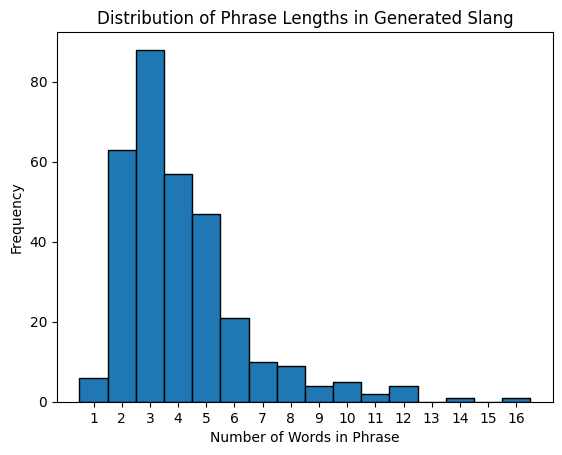

In [23]:
num_words = [len(phrase.split()) for phrase in multi_worded]
num_words_single = [1 for phrase in single_worded]

total_num_words = num_words + num_words_single
plt.hist(total_num_words, bins=range(1, max(total_num_words)+2), align='left', edgecolor='black')
plt.xlabel('Number of Words in Phrase')
plt.ylabel('Frequency')
plt.title('Distribution of Phrase Lengths in Generated Slang')
plt.xticks(range(1, max(total_num_words)+1))
plt.show()

In [24]:
unique_words = []
total_checked = len(single_worded)

for word in single_worded:
    # We assume word_exists(word) returns True if found in Oxford/Urban/Reddit
    # So 'not exists' means the word is unique to your current input
    if not word_exists(word, Silent = True):
        unique_words.append(word)

# Calculate the proportion
proportion_unique = len(unique_words) / total_checked if total_checked > 0 else 0

# Results
print(f"Proportion of unique words: {proportion_unique:.2%}")
print(f"Number of unique words: {len(unique_words)} out of {total_checked}")
print("-" * 30)
print("List of Unique Words:")
print(unique_words)

NameError: name 'word_exists' is not defined

In [20]:
reddit_scores = []

for i in multi_worded[:10]:
    score = reddit_calculate_uniqueness(i, 2, corpus_ngram_freq)
    reddit_scores.append(score)
    print(f"Reddit Commonality Score: {i} {score:.2%}")

Reddit Commonality Score: level up 100.00%
Reddit Commonality Score: ghosted me 100.00%
Reddit Commonality Score: vibe check 0.00%
Reddit Commonality Score: raining cats and dogs 66.67%
Reddit Commonality Score: salty af 0.00%
Reddit Commonality Score: dial it back 100.00%
Reddit Commonality Score: main character energy 50.00%
Reddit Commonality Score: caught dead 100.00%
Reddit Commonality Score: smooth operator 100.00%
Reddit Commonality Score: spill the beans 100.00%


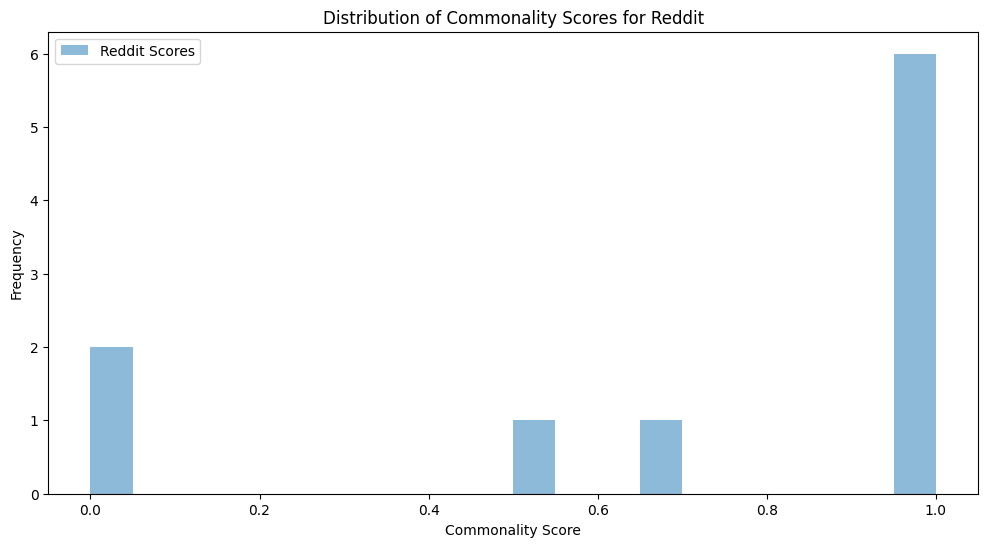

In [21]:
# histogram of reddit commonality scores
plt.figure(figsize=(12, 6))
plt.hist(reddit_scores, bins=20, alpha=0.5, label='Reddit Scores')
plt.xlabel('Commonality Score')
plt.ylabel('Frequency')
plt.title('Distribution of Commonality Scores for Reddit')
plt.legend()
plt.show()

In [22]:
reddit_tokens = [token for sublist in reddit_tokenized for token in sublist]
reddit_freq = FreqDist(ngrams(reddit_tokens, 2))

# 2. Build Movie Map
movie_tokens = [token for sublist in all_tokens for token in sublist] # assuming you have movie_tokenized
movie_freq = FreqDist(ngrams(movie_tokens, 2))

In [23]:
def calculate_corpus_score(expression, n, freq_dist, label="Corpus"):
    """
    Calculates what percentage of an expression's n-grams exist in a given frequency map.
    """
    expr_tokens = word_tokenize(expression.lower())
    expr_ngrams = list(ngrams(expr_tokens, n))
    
    if not expr_ngrams:
        return 0.0
    
    # Fast O(1) lookup in the frequency map
    present_count = sum(1 for gram in expr_ngrams if gram in freq_dist)
    proportion_present = present_count / len(expr_ngrams)
    
    return proportion_present

In [24]:
test_phrase = "that rizz is actually insane"

# Get scores for both
r_score = calculate_corpus_score(test_phrase, 2, reddit_freq)
m_score = calculate_corpus_score(test_phrase, 2, movie_freq)

print(f"Phrase: {test_phrase}")
print(f"Reddit Commonality: {r_score:.2%}")
print(f"Movie Commonality: {m_score:.2%}")

if r_score > m_score:
    print("Verdict: This sounds more like a Reddit/Social Media comment.")
else:
    print("Verdict: This sounds more like scripted Movie dialogue.")

Phrase: that rizz is actually insane
Reddit Commonality: 50.00%
Movie Commonality: 0.00%
Verdict: This sounds more like a Reddit/Social Media comment.


In [25]:
test_phrase = "hello there"

# Get scores for both
r_score = calculate_corpus_score(test_phrase, 2, reddit_freq)
m_score = calculate_corpus_score(test_phrase, 2, movie_freq)

print(f"Phrase: {test_phrase}")
print(f"Reddit Commonality: {r_score:.2%}")
print(f"Movie Commonality: {m_score:.2%}")

if r_score > m_score:
    print("Verdict: This sounds more like a Reddit/Social Media comment.")
else:
    print("Verdict: This sounds more like scripted Movie dialogue.")

Phrase: hello there
Reddit Commonality: 100.00%
Movie Commonality: 0.00%
Verdict: This sounds more like a Reddit/Social Media comment.


In [26]:
r_scores = []
m_scores = []
rvm = []

for phrase in multi_worded[:10]:
    r_score = calculate_corpus_score(phrase, 2, reddit_freq)
    m_score = calculate_corpus_score(phrase, 2, movie_freq)

    r_scores.append(r_score)
    m_scores.append(m_score)
    
    if r_score > m_score:
        rvm.append(0) # Reddit
    else:
        rvm.append(1) # Movie
    

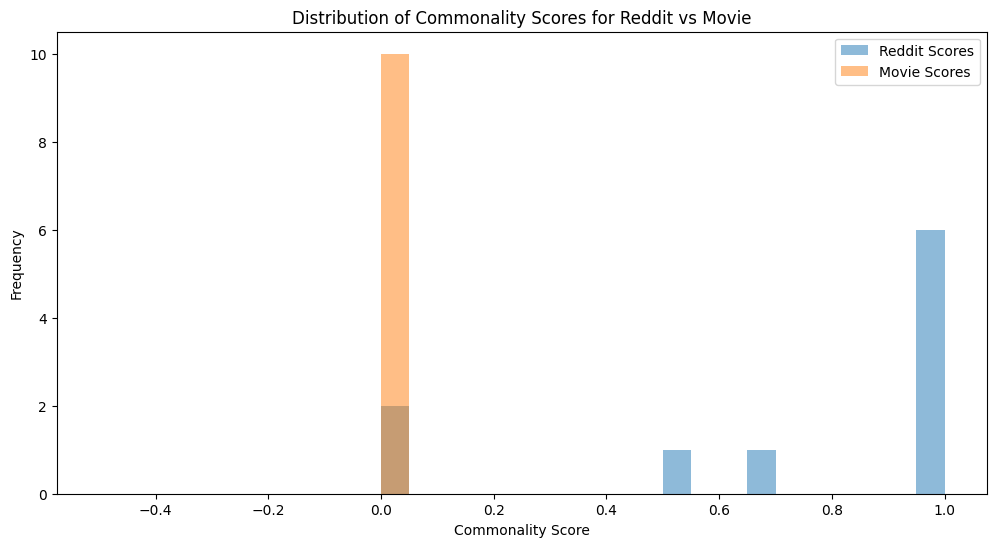

In [27]:
# histogram of Reddit vs Movie scores
plt.figure(figsize=(12, 6))
plt.hist(r_scores, bins=20, alpha=0.5, label='Reddit Scores')
plt.hist(m_scores, bins=20, alpha=0.5, label='Movie Scores')
plt.xlabel('Commonality Score')
plt.ylabel('Frequency')
plt.title('Distribution of Commonality Scores for Reddit vs Movie')
plt.legend()
plt.show()

In [28]:
#reddit doesnt look like its working
ds = load_dataset("MLBtrio/genz-slang-dataset")

# Convert the 'train' split to a Pandas DataFrame
genz = pd.DataFrame(ds['train'])

In [29]:
print("Dataset Summary")
print(f'{len(genz.columns)} columns: {genz.columns}')
print(f'Number of entries: {len(genz)}')

Dataset Summary
4 columns: Index(['Slang', 'Description', 'Example', 'Context'], dtype='object')
Number of entries: 1779


In [30]:
all_text = " ".join(genz['Example'].fillna('').astype(str).str.lower())

# 2. Tokenize and build the global FreqDist
# n=2 for bigrams as in your example
all_tokens = word_tokenize(all_text)
corpus_ngram_freq = FreqDist(ngrams(all_tokens, 2))

print(f"Total unique bigrams in corpus: {len(corpus_ngram_freq)}")

def calculate_slang_commonality(expression, n, freq_map):
    # Tokenize input
    expr_tokens = word_tokenize(expression.lower())
    expr_ngrams = list(ngrams(expr_tokens, n))
    
    if not expr_ngrams:
        return 0.0
    
    # Fast dictionary lookup
    # We check if the tuple (gram) exists in our FreqDist keys
    present_count = sum(1 for gram in expr_ngrams if gram in freq_map)
    
    # Calculate proportion
    proportion_present = present_count / len(expr_ngrams)
    return proportion_present

# --- Testing ---
test_phrase = "no cap that video was fire"
score = calculate_slang_commonality(test_phrase, 2, corpus_ngram_freq)

print(f"Expression: '{test_phrase}'")
print(f"Slang Commonality: {score:.2%}")

Total unique bigrams in corpus: 8513
Expression: 'no cap that video was fire'
Slang Commonality: 40.00%


In [25]:
r_scores = []
m_scores = []
g_scores = []
rvm = [] # 0: Reddit, 1: Movie, 2: GenZ (Slang)

for phrase in multi_worded[:10]:
    r_score = calculate_corpus_score(phrase, 2, reddit_freq)
    m_score = calculate_corpus_score(phrase, 2, movie_freq)
    g_score = calculate_slang_commonality(phrase, 2, corpus_ngram_freq)

    r_scores.append(r_score)
    m_scores.append(m_score)
    g_scores.append(g_score)
    
    # --- Classification Logic ---
    # Priority 1: If it's heavy on GenZ slang
    if g_score > 0.4: 
        rvm.append(2) # GenZ / Slang
    # Priority 2: Standard Reddit vs Movie comparison
    elif r_score > m_score:
        rvm.append(0) # Reddit
    else:
        rvm.append(1) # Movie

plt.figure(figsize=(12, 6))

# Plotting all three distributions
plt.hist(r_scores, bins=20, alpha=0.5, label='Reddit Scores', color='orange')
plt.hist(m_scores, bins=20, alpha=0.5, label='Movie Scores', color='blue')
plt.hist(g_scores, bins=20, alpha=0.5, label='GenZ Slang Scores', color='green')

plt.xlabel('Commonality (Proportion of n-grams found)')
plt.ylabel('Number of Phrases')
plt.title('Distribution of Commonality: Reddit vs. Movie vs. GenZ Slang')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

NameError: name 'calculate_corpus_score' is not defined

In [32]:
#new semantic fluency baseline, Syntactic Density Metric - Surface-Level Linguistic Analysis
#Uses POS patterns to check for "illegal" grammatical moves.
#The function breaks down a sentence into its grammatical "skeleton" and applies two specific penalties
#based on how English is typically structured:
#It looks for any tag starting with VB (e.g., VB, VBD, VBG). If none are found, it assumes the phrase 
#is a "fragment" or a "list" rather than a fluent sentence, applying a 40% penalty.
#It tracks the "Noun Stack" (tags starting with NN). If it finds 4+ nouns in a row ("rizz gyat skibidi sigma")
#, it flags this as "low-fluency" and applies a 30% penalty.
from nltk import word_tokenize, pos_tag

# Ensure the tagger is ready
#nltk.download('punkt')
#nltk.download('averaged_perceptron_tagger')

def get_pos_fluency_score(text):
    tokens = word_tokenize(text.lower())
    if not tokens: return 0.0
    
    tags = [tag for word, tag in pos_tag(tokens)]
    
    # 1. Check for "Slang-Heavy" sequences (Noun-Noun-Noun-Noun)
    # Fluent English usually interleaves verbs/prepositions
    noun_stack = 0
    max_noun_stack = 0
    for tag in tags:
        if tag.startswith('NN'): # NN, NNS, NNP
            noun_stack += 1
            max_noun_stack = max(max_noun_stack, noun_stack)
        else:
            noun_stack = 0
            
    # 2. Penalty for lack of Verbs (Sentences usually need a 'root' action)
    has_verb = any(tag.startswith('VB') for tag in tags)
    
    # Simple Heuristic: 
    # High score = has a verb & doesn't just stack 5 nouns in a row
    score = 1.0
    if not has_verb: score -= 0.4
    if max_noun_stack > 3: score -= 0.3
    
    return max(0.1, score)

# Example:
print(f"Fluent: {get_pos_fluency_score('The cat sat on the mat.')}")
print(f"Slang Stack: {get_pos_fluency_score('rizz gyat skibidi fanum tax')}")

Fluent: 1.0
Slang Stack: 0.3


In [74]:
#single_worded
#multi_worded
#get_pos_fluency_score(text):
#z_score = calculate_slang_commonality(test_phrase, 2, corpus_ngram_freq)
#r_score = calculate_corpus_score(test_phrase, 2, reddit_freq)
#m_score = calculate_corpus_score(test_phrase, 2, movie_freq)
#word_exists(word, Silent = False):

#start with the single worded dictionary lookup
unique_words = set()
for word in single_worded:
    if not word_exists(word, Silent = True):
        unique_words.add(word)

# Calculate the proportion
proportion_unique = len(unique_words) /len(single_worded) if len(single_worded) > 0 else 0

# Results
print(f"Proportion of unique words: {proportion_unique:.2%}")
print(f"Number of unique words: {len(unique_words)} out of {len(single_worded)}")
print("-" * 30)
print("List of Unique Words:")
print(unique_words)

#expression dictionary lookup?
unique_words = set()
average = 0
for expression in multi_worded:
    for word in expression:
        average = average +1
        if not word_exists(word, Silent = True):
            unique_words.add(word)

# Calculate the proportion
proportion_unique = len(unique_words) /average if average > 0 else 0

# Results
print(f"Proportion of unique words: {proportion_unique:.2%}")
print(f"Number of unique words: {len(unique_words)} out of {average}")
print("-" * 30)
print("List of Unique Words:")
print(unique_words)

Proportion of unique words: 50.00%
Number of unique words: 2 out of 4
------------------------------
List of Unique Words:
{' off-grid', ' weather-eye'}
Proportion of unique words: 0.14%
Number of unique words: 5 out of 3572
------------------------------
List of Unique Words:
{')', '(', 'ి', '/', '’'}


In [26]:
processed_phrases = [" ".join(p) if isinstance(p, list) else p for p in multi_worded]
scores = [get_pos_fluency_score(phrase) for phrase in processed_phrases]

# 2. Basic Stats
avg_score = sum(scores) / len(scores)
print(f"Total phrases analyzed: {len(scores)}")
print(f"Mean Fluency Score: {avg_score:.2f}")

plt.figure(figsize=(10, 6))

# Create the Histogram
n, bins, patches = plt.hist(scores, bins=10, range=(0.1, 1.0), 
                            color='#3498db', edgecolor='white', alpha=0.8)

# Add vertical lines for your specific cutoffs
plt.axvline(0.4, color='#e74c3c', linestyle='--', linewidth=2, label='Slang/Fragment Boundary (0.4)')
plt.axvline(0.7, color='#2ecc71', linestyle='--', linewidth=2, label='Fluent English Boundary (0.7)')

# Aesthetics
plt.title('Syntactic Cohesion: Distribution of POS Fluency Scores', fontsize=14, pad=15)
plt.xlabel('Fluency Score (0.1 = Low, 1.0 = High)', fontsize=12)
plt.ylabel('Number of Expressions', fontsize=12)
plt.xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# Add a light horizontal grid for readability
plt.gca().yaxis.grid(True, linestyle=':', alpha=0.6)
plt.gca().set_axisbelow(True) # Puts grid behind bars

plt.legend(loc='upper left')
plt.tight_layout()

plt.show()

NameError: name 'get_pos_fluency_score' is not defined

Successfully loaded 382 scores.
File Threshold detected: 0.95


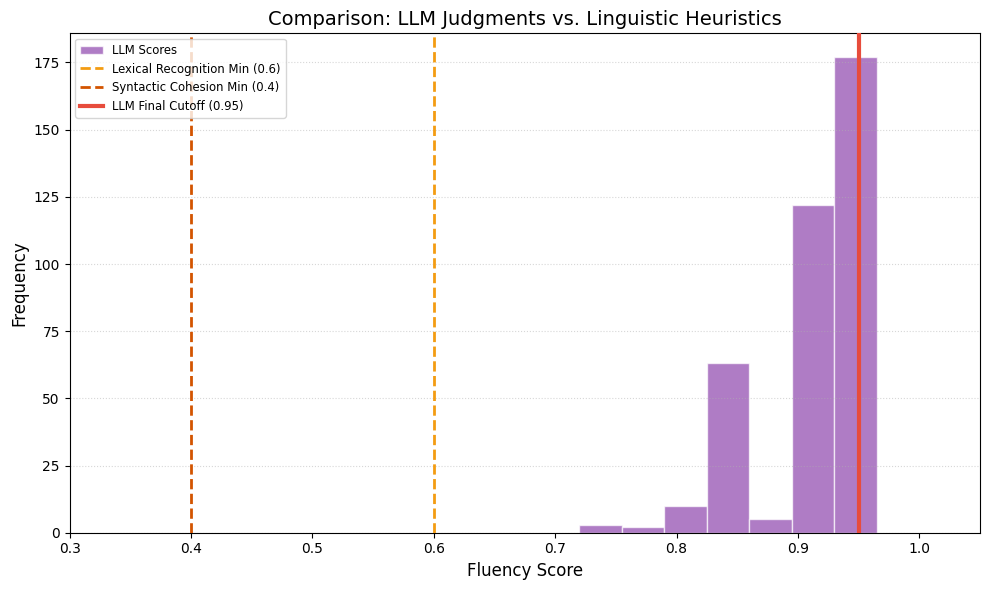

In [76]:
scores = []
scores = []
llm_cutoff = 0.0 # This will be our holder for the file's threshold

try:
    with open("zero_shot.txt", 'r') as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]
        
        # Line 1: The Threshold (0.95)
        llm_cutoff = float(lines[0])
        
        # Lines 2+: The numbered list
        for line in lines[1:]:
            # Grabbing the last element (the score) to avoid index/number confusion
            val = line.split()[-1]
            scores.append(float(val))

    print(f"Successfully loaded {len(scores)} scores.")
    print(f"File Threshold detected: {llm_cutoff}")

except Exception as e:
    print(f"Error reading file: {e}")

# 2. Plotting
plt.figure(figsize=(10, 6))

# Histogram
plt.hist(scores, bins=20, range=(0.3, 1.0), color='#8e44ad', edgecolor='white', alpha=0.7, label='LLM Scores')

# --- Linguistic Heuristics ---
plt.axvline(x=0.6, color='#f39c12', linestyle='--', linewidth=2, 
            label='Lexical Recognition Min (0.6)', zorder=4)

plt.axvline(x=0.4, color='#d35400', linestyle='--', linewidth=2, 
            label='Syntactic Cohesion Min (0.4)', zorder=4)

# --- LLM Final Cutoff ---
# We use llm_cutoff here so it matches the file exactly
plt.axvline(x=llm_cutoff, color='#e74c3c', linestyle='-', linewidth=3, 
            label=f'LLM Final Cutoff ({llm_cutoff})', zorder=5)

# Formatting
plt.xlim(0.3, 1.05)
plt.title('Comparison: LLM Judgments vs. Linguistic Heuristics', fontsize=14)
plt.xlabel('Fluency Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.legend(loc='upper left', fontsize='small')
plt.tight_layout()

plt.show()

In [2]:
#now for llm judge
from transformers import pipeline
from transformers import BitsAndBytesConfig
import torch
import transformers
print(transformers.__version__)
print(transformers.__file__)

5.3.0.dev0
C:\Users\brock\miniconda3\envs\cs116\lib\site-packages\transformers\__init__.py


In [3]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

pipe = pipeline(
    "image-text-to-text",
    model="google/gemma-3-12b-it",
    device_map="auto", # Automatically handles the 4070 allocation
    model_kwargs={"quantization_config": quant_config}
)

STOP_WORD = "###DONE###"

Loading weights:   0%|          | 0/1065 [00:00<?, ?it/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [27]:
target_list = single_worded + multi_worded
cropped_list = []
for i in target_list:
    cropped_list.append(i.strip(' '))
print(cropped_list)
print(len(cropped_list))

['off-grid', 'downhearted', 'matchmaker', 'weather-eye', 'mouthpiece', 'wing-man', "climb one's ladder", 'get radio silence', 'read people', 'deluge at sea', 'leave crumbs on one’ post', 'fume mill', 'dial back', 'star yourself up', 'bring shame upon someone; shun', 'smooth operator', 'spill some tea', 'deep at sea', 'temporary walkie talkies', "searching your hand up someone's sleeves", 'fancy footwork', 'stone finger', 'turn thumbs up', 'bad news bearer', "See ya alliteration's!", 'moon about', 'water under teh bridge', 'spit straight about it', 'call it off if I have done enough', 'get off on high cotton', 'dressing table setting', 'voice in your bones', 'on point fashionably dressed', 'race before burying oneself in thought', 'sitting on in-tray', 'rock as if all is well on sea', 'kick off; bottom out', 'open up some tabernacles', 'shadow cabinet', 'do as they preach', 'stand on guard', 'drop out completely', 'soak up sunshine', 'roll call', "rain on one's parade", 'spoil milk', 'v

In [28]:
input_text = f"Analyze the following list of expressions for semantic fluency: {cropped_list}"

messages = [
    {
        "role": "system",
        "content": [{
            "type": "text", 
            "text": """You are an expert Computational Linguist. Your task is to analyze 'Semantic Fluency' based on two criteria:
            1. For Single Words: Evaluate if the word is a recognized lexical unit or established slang within digital subcultures including idiomatic expresions (e.g., Reddit/GenZ).
            2. For Multi-word Phrases: Evaluate the 'Syntactic Cohesion'—does the phrase follow natural English Part-of-Speech transitions, even if using informal slang or expressions?
            
            Provide a 'Fluency Score' (0.0-1.0) for each.
            
            OUTPUT RULES:
        - Line 1: Provide the cutoff thresholds.
        - Subsequent Lines: Provide the score for each entry. 
        - FORMAT: Number the list (e.g., '1. 0.85') to ensure every item is captured.
        - TERMINATION: After the 267th score, immediately type '{stop_token}' and stop.
        - No other text is allowed."""
        }]
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": input_text}
        ]
    }
]

output = pipe(
    messages, 
    max_new_tokens=2000, 
    do_sample=False, 
    stop_strings=[STOP_WORD],
    tokenizer=pipe.tokenizer
)
raw_content = output[0]["generated_text"][-1]["content"]
# Split by lines, skip the first (cutoff) and last (DONE), then extract the float
scores = [float(line.split(". ")[1]) for line in raw_content.strip().split("\n")[1:-1]]
print(scores)

Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[0.9, 0.95, 0.8, 0.85, 0.75, 0.92, 0.88, 0.7, 0.2, 0.45, 0.3, 0.65, 0.35, 0.98, 0.85, 0.4, 0.25, 0.6, 0.7, 0.35, 0.45, 0.5, 0.2, 0.75, 0.65, 0.6, 0.8, 0.65, 0.55, 0.6, 0.3, 0.5, 0.85, 0.7, 0.95, 0.9, 0.8, 0.8, 0.75, 0.7, 0.65, 0.9, 0.88, 0.55, 0.8, 0.5, 0.98, 0.95, 0.95, 0.85, 0.6, 0.95, 0.65, 0.6, 0.85, 0.98, 0.7, 0.6, 0.6, 0.75, 0.88, 0.95, 0.9, 0.85, 0.8, 0.92, 0.9, 0.95, 0.55, 0.95, 0.6, 0.95, 0.65, 0.8, 0.88, 0.85, 0.98, 0.95, 0.95, 0.98, 0.95, 0.95, 0.9, 0.85, 0.9, 0.98, 0.75, 0.8, 0.88, 0.95, 0.85, 0.75, 0.9, 0.7, 0.65, 0.7, 0.95, 0.75, 0.98, 0.95, 0.85, 0.85, 0.85, 0.95, 0.98, 0.7, 0.9, 0.95, 0.75, 0.88, 0.95, 0.85, 0.7, 0.8, 0.9, 0.75, 0.98, 0.7, 0.95, 0.85, 0.95, 0.75, 0.6, 0.6, 0.88, 0.9, 0.95, 0.65, 0.55, 0.5, 0.6, 0.98, 0.65, 0.75, 0.8, 0.8, 0.85, 0.8, 0.9, 0.85, 0.65, 0.85, 0.7, 0.55, 0.65, 0.75, 0.8, 0.6, 0.6, 0.9, 0.95, 0.65, 0.7, 0.6, 0.95, 0.95, 0.65, 0.75, 0.9, 0.6, 0.9, 0.98, 0.85, 0.88, 0.95, 0.8, 0.88, 0.85, 0.9, 0.95, 0.5, 0.65, 0.8, 0.95, 0.8, 0.85, 0.65, 0.6, 0

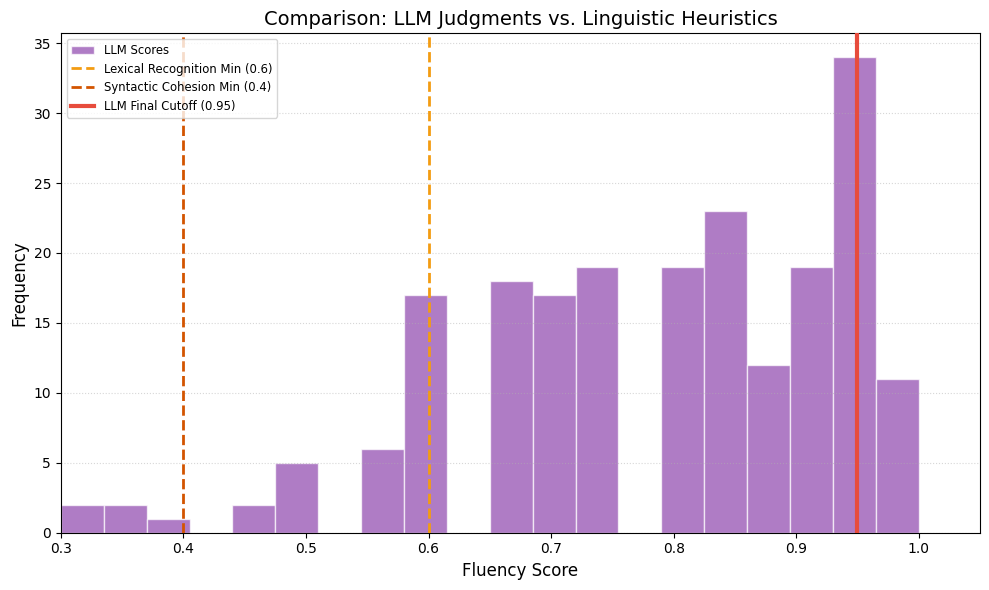

In [29]:
import requests
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
# 2. Plotting
plt.figure(figsize=(10, 6))

# Histogram
plt.hist(scores, bins=20, range=(0.3, 1.0), color='#8e44ad', edgecolor='white', alpha=0.7, label='LLM Scores')

# --- Linguistic Heuristics ---
plt.axvline(x=0.6, color='#f39c12', linestyle='--', linewidth=2, 
            label='Lexical Recognition Min (0.6)', zorder=4)

plt.axvline(x=0.4, color='#d35400', linestyle='--', linewidth=2, 
            label='Syntactic Cohesion Min (0.4)', zorder=4)

# --- LLM Final Cutoff ---
# We use llm_cutoff here so it matches the file exactly
plt.axvline(x=.95, color='#e74c3c', linestyle='-', linewidth=3, 
            label=f'LLM Final Cutoff ({0.95})', zorder=5)

# Formatting
plt.xlim(0.3, 1.05)
plt.title('Comparison: LLM Judgments vs. Linguistic Heuristics', fontsize=14)
plt.xlabel('Fluency Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.legend(loc='upper left', fontsize='small')
plt.tight_layout()

plt.show()

In [9]:
print(raw_content)

0.  Cutoff Thresholds: Lexical (0.6), Syntactic (0.4)

1.  0.25
2.  0.15
3.  0.25
4.  0.35
5.  0.15
6.  0.35
7.  0.15
8.  0.35
9.  0.15
10. 0.35
11. 0.35
12. 0.35
13. 0.15
14. 0.35
15. 0.35
16. 0.35
17. 0.35
18. 0.35
19. 0.35
20. 0.35
21. 0.35
22. 0.35
23. 0.35
24. 0.35
25. 0.35
26. 0.35
27. 0.35
28. 0.45
29. 0.45
30. 0.45
31. 0.45
32. 0.45
33. 0.25
34. 0.35
35. 0.35
36. 0.35
37. 0.35
38. 0.35
39. 0.35
40. 0.45
41. 0.45
42. 0.45
43. 0.45
44. 0.45
45. 0.45
46. 0.35
47. 0.45
48. 0.45
49. 0.45
50. 0.45
51. 0.35
52. 0.35
53. 0.35
54. 0.45
55. 0.45
56. 0.45
57. 0.45
58. 0.45
59. 0.45
60. 0.35
61. 0.35
62. 0.45
63. 0.45
64. 0.45
65. 0.45
66. 0.45
67. 0.45
68. 0.45
69. 0.35
70. 0.35
71. 0.35
72. 0.45
73. 0.45
74. 0.45
75. 0.45
76. 0.45
77. 0.45
78. 0.35
79. 0.35
80. 0.45
81. 0.45
82. 0.45
83. 0.45
84. 0.45
85. 0.45
86. 0.35
87. 0.35
88. 0.35
89. 0.45
90. 0.45
91. 0.45
92. 0.45
93. 0.45
94. 0.45
95. 0.35
96. 0.35
97. 0.35
98. 0.45
99. 0.45
100. 0.45
101. 0.45
102. 0.45
103. 0.45
104. 0.35
105.

In [9]:
print(len(scores))

224
